# Preparing and cleaning data

In [1]:
DATA_DIR = 'data/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE = DATA_DIR + 'sales_test.csv'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Master
products = pd.read_csv(DATA_DIR + 'products.csv')
customers = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date']) #
promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date']) #
geography = pd.read_csv(DATA_DIR + 'geography.csv')
# Transaction
orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date']) #
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
payments = pd.read_csv(DATA_DIR + 'payments.csv')
shipments = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date', 'delivery_date']) #
returns = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date']) #
reviews = pd.read_csv(DATA_DIR + 'reviews.csv', parse_dates=['review_date']) #
# Analytical
sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date']) #
# Operational
inventory = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date']) #
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')

In [4]:
def quick_check(df, df_name):
    print(f"\n{'='*10} CHECKING TABLE: {df_name} {'='*10}")
    # Overall
    df.info()
    print(df.describe())

    # 1. Duplicates
    print(f"Duplicates: {df.duplicated().sum()} rows")

    # 2. Null values
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print("Nulls found:\n", null_counts[null_counts > 0])
    else:
        print("No null values.")

    # 3. Shape
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

In [5]:
quick_check(products, 'products')
quick_check(customers, 'customers')
quick_check(promotions, 'promotions')
quick_check(geography, 'geography')
quick_check(orders, 'orders')
quick_check(order_items, 'order_items')
quick_check(payments, 'payments')
quick_check(shipments, 'shipments')
quick_check(returns, 'returns')
quick_check(reviews, 'reviews')
quick_check(sales, 'sales')
quick_check(inventory, 'inventory')
quick_check(web_traffic, 'web_traffic')


========== CHECKING TABLE: products ==========
<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   str    
 2   category      2412 non-null   str    
 3   segment       2412 non-null   str    
 4   size          2412 non-null   str    
 5   color         2412 non-null   str    
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 150.9 KB
        product_id         price          cogs
count  2412.000000   2412.000000   2412.000000
mean   1206.500000   4928.216231   3868.346732
std     696.428747   4776.737669   3878.584151
min       1.000000      9.056594      5.183829
25%     603.750000     59.444924     35.066367
50%    1206.500000   4399.605000   3184.934093
75%    1809.250000   7720.513784   586

In [6]:
invalid_products = products[products['cogs'] >= products['price']]
len(invalid_products)

0

In [7]:
promotions['applicable_category'] = promotions['applicable_category'].fillna('Any')

In [8]:
order_items['promo_id'] = order_items['promo_id'].fillna('No_Promo')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('No_Promo')

# EDA

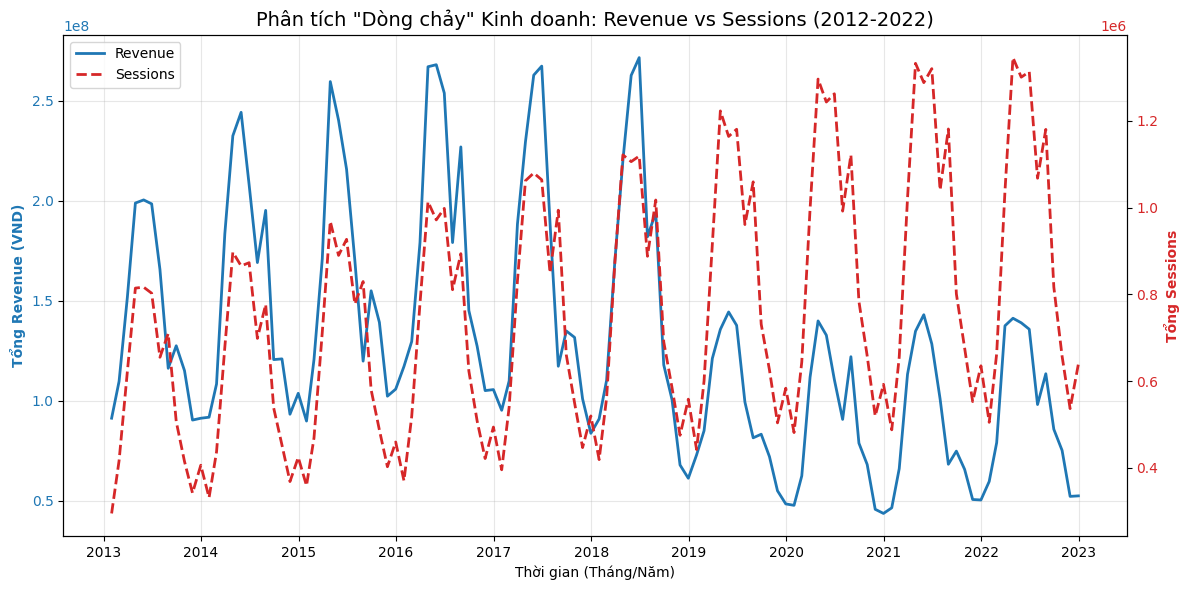

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tiền xử lý dữ liệu
# Đảm bảo cột 'date' được chuyển sang định dạng Datetime
# Errors='coerce' sẽ giúp xử lý các dòng có ngày tháng bị lỗi (nếu có)
web_traffic['date'] = pd.to_datetime(web_traffic['date'], errors='coerce')
sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')

# 2. Tổng hợp dữ liệu theo tháng (Resampling)
# Sử dụng 'ME' cho phiên bản Pandas mới
monthly_sales = sales.resample('ME', on='Date')['Revenue'].sum().reset_index()

# Giờ đây cột 'date' đã là DatetimeIndex nên lệnh này sẽ chạy bình thường
monthly_traffic = web_traffic.resample('ME', on='date')['sessions'].sum().reset_index()

# 3. Kết hợp hai bảng dữ liệu theo tháng
# Lưu ý: Cột 'Date' từ sales và 'date' từ web_traffic
df_merged = pd.merge(monthly_sales, monthly_traffic, left_on='Date', right_on='date')
df_merged = df_merged[['Date', 'Revenue', 'sessions']]

# 4. Vẽ biểu đồ trục kép (Dual-axis chart)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục 1: Revenue
color_rev = 'tab:blue'
ax1.set_xlabel('Thời gian (Tháng/Năm)')
ax1.set_ylabel('Tổng Revenue (VND)', color=color_rev, fontweight='bold')
ax1.plot(df_merged['Date'], df_merged['Revenue'], color=color_rev, label='Revenue', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_rev)

# Trục 2: Sessions
ax2 = ax1.twinx()
color_ses = 'tab:red'
ax2.set_ylabel('Tổng Sessions', color=color_ses, fontweight='bold')
ax2.plot(df_merged['Date'], df_merged['sessions'], color=color_ses, label='Sessions', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_ses)

# 5. Chú thích và Tiêu đề
plt.title('Phân tích "Dòng chảy" Kinh doanh: Revenue vs Sessions (2012-2022)', fontsize=14)
fig.tight_layout()
ax1.grid(True, alpha=0.3)

# Gộp chú thích
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

Để trực quan hơn, thì đây là tỉ lệ chuyển đổi từ sang đơn hàng từ các session:

In [10]:
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
web_traffic['date'] = pd.to_datetime(web_traffic['date'], errors='coerce')
sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')

# 2. Tổng hợp dữ liệu theo năm
yearly_orders = orders.resample('YE', on='order_date')['order_id'].nunique().reset_index()
yearly_orders.columns = ['Year', 'Order_Count']

# Tổng sessions mỗi năm 
yearly_sessions = web_traffic.resample('YE', on='date')['sessions'].sum().reset_index()
yearly_sessions.columns = ['Year', 'Total_Sessions']

yearly_revenue = sales.resample('YE', on='Date')['Revenue'].sum().reset_index()
yearly_revenue.columns = ['Year', 'Total_Revenue']

# 3. Kết hợp các bảng dữ liệu lại với nhau
df_yearly = pd.merge(yearly_orders, yearly_sessions, on='Year', how='inner')
df_yearly = pd.merge(df_yearly, yearly_revenue, on='Year', how='inner')

# Conversion Rate (%) = (Số đơn hàng / Số lượt truy cập) * 100
df_yearly['Conversion_Rate (%)'] = (df_yearly['Order_Count'] / df_yearly['Total_Sessions']) * 100

# Average Order Value (AOV) = Tổng doanh thu / Số đơn hàng
df_yearly['AOV'] = df_yearly['Total_Revenue'] / df_yearly['Order_Count']

df_yearly['Year'] = df_yearly['Year'].dt.year
df_yearly = df_yearly.round({'Conversion_Rate (%)': 2, 'AOV': 0, 'Total_Revenue': 0})

# 6. Hiển thị kết quả
print("PHÂN TÍCH HIỆU SUẤT KINH DOANH THEO NĂM (2012-2022):")
print(df_yearly[['Year', 'Total_Sessions', 'Order_Count', 'Total_Revenue', 'Conversion_Rate (%)', 'AOV']].to_string(index=False))


PHÂN TÍCH HIỆU SUẤT KINH DOANH THEO NĂM (2012-2022):
 Year  Total_Sessions  Order_Count  Total_Revenue  Conversion_Rate (%)     AOV
 2013         6801940        76849   1657169417.0                 1.13 21564.0
 2014         7340960        80645   1871845883.0                 1.10 23211.0
 2015         7861938        82622   1889933827.0                 1.05 22874.0
 2016         8403399        82247   2104640678.0                 0.98 25589.0
 2017         8992602        76010   1911164325.0                 0.85 25144.0
 2018         9415085        69510   1850122456.0                 0.74 26617.0
 2019         9990148        41601   1136801442.0                 0.42 27326.0
 2020        10591082        34881   1054512159.0                 0.33 30232.0
 2021        10991725        34525   1043039820.0                 0.31 30211.0
 2022        11063658        36004   1169748832.0                 0.33 32489.0


## Xu hướng tăng trưởng
### Giai đoạn 2012 - 2018
- Doanh thu và lưu lượng truy cập có sự đồng nhất cao. Khi lượt truy cập tăng, doanh thu tăng tương ứng, cho thấy hiệu quả vận hành ổn định. 
- Trong đó, tỉ lệ chuyển hóa từ lượt truy cập thành đơn hàng vào các năm 2013, 2014, 2015 lại vượt mức 100%, cho thấy mức tăng trưởng vượt kỳ vọng. Những năm sau đó thì tỉ lệ chuyển hóa lượng truy cập sang đơn hàng tuy có giảm, nhưng hiệu quả vẫn trên 50%, cho thấy được các sản phẩm của hãng vẫn còn giữ được sức mua.

### Giai đoạn 2019 - 2022
- Xuất hiện sự "lệch pha" nghiêm trọng. Trong khi Sessions tiếp tục lập các đỉnh mới (vượt mức $1.2$ triệu lượt mỗi tháng, còn tổng lượng truy cập cả năm thì vượt mức 11 triệu), thì Revenue lại có xu hướng giảm dần, không thể quay lại các đỉnh cao như giai đoạn 2017-2018.
- Đặc biệt nhất có thể kể đến điểm rơi giữa 2 năm chuyển giai đoạn 2018 - 2019, khi mà hiệu số của tỉ lệ chuyển hóa của 2 năm đạt mức cao kỷ lục: 0.32, trong khi lưu lượng truy cập vẫn tăng liên tục.
- Trong 3 năm kế tiếp mà số liệu được thu thập, tỉ lệ chuyển hóa chỉ dao động trong khoảng 0.33%, nghĩa là cứ 3 lượt truy cập thì chỉ quy đổi ra được 1 đơn hàng, cho thấy sự dậm chân tại chỗ của doanh nghiệp

## Giải mã vấn đề

### Giả thiết: Kho vận (inventory) có vấn đề gì không?

PHÂN TÍCH KHO CỦA TOP 20% SẢN PHẨM CHỦ LỰC QUA 2 GIAI ĐOẠN:


,Phase,Avg Stockout Days / Month,Avg Fill Rate,Stockout Probability,Overstock Probability
0,2012-2018,1.260141,0.957995,0.671224,0.851702
1,2019-2022,1.032667,0.965578,0.666422,0.977489


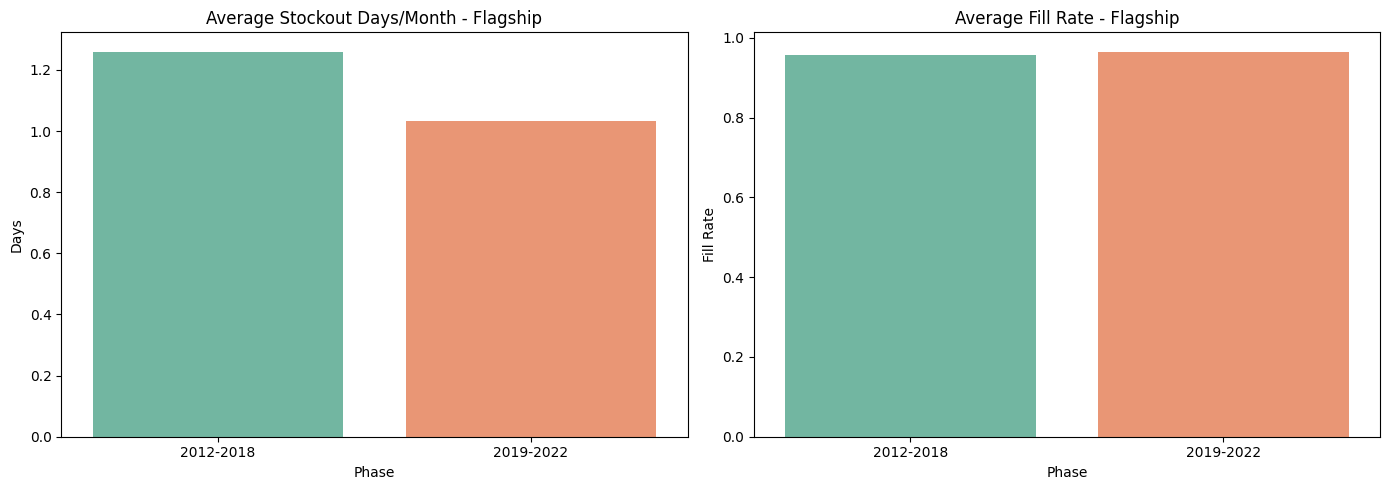


PHÂN TÍCH TOÀN BỘ KHO CHUNG:


,Phase,units_sold,stock_on_hand,units_received,stockout_flag,overstock_flag,sell_through_rate
0,2012-2018,724492,6050796,851425,0.675544,0.745176,0.168052
1,2019-2022,204382,5353868,235841,0.669797,0.792013,0.125546


In [11]:
# Tính tổng doanh số của từng sản phẩm để xác định 'Sản phẩm chủ lực' (Flagship/Best-sellers)
product_sales = inventory.groupby(['product_id', 'product_name'])['units_sold'].sum().reset_index()
product_sales = product_sales.sort_values(by='units_sold', ascending=False)

# Giả thuyết: Top 20% sản phẩm bán ra nhiều nhất chính là dòng sản phẩm chủ lực (theo quy tắc Pareto 80/20)
top_20_cutoff = int(len(product_sales) * 0.2)
top_products = product_sales.head(top_20_cutoff)['product_id'].tolist()

# Đánh nhãn giai đoạn cho dữ liệu tồn kho
inventory['Phase'] = inventory['year'].apply(lambda x: '2012-2018' if x <= 2018 else '2019-2022')

# Lọc thông tin kho của các sản phẩm chủ lực
flagship_inventory = inventory[inventory['product_id'].isin(top_products)]

# Phân tích các chỉ số kho vận cho SẢN PHẨM CHỦ LỰC qua 2 giai đoạn
flagship_analysis = flagship_inventory.groupby('Phase').agg({
    'stockout_days': 'mean',
    'fill_rate': 'mean',
    'stockout_flag': 'mean', # Tỉ lệ % số tháng/sản phẩm rơi vào trạng thái hết hàng
    'overstock_flag': 'mean' 
}).reset_index()

flagship_analysis.rename(columns={
    'stockout_days': 'Avg Stockout Days / Month',
    'fill_rate': 'Avg Fill Rate',
    'stockout_flag': 'Stockout Probability',
    'overstock_flag': 'Overstock Probability'
}, inplace=True)

print("PHÂN TÍCH KHO CỦA TOP 20% SẢN PHẨM CHỦ LỰC QUA 2 GIAI ĐOẠN:")
display(flagship_analysis)

# Trực quan hóa
import warnings
warnings.filterwarnings('ignore')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=flagship_inventory, x='Phase', y='stockout_days', ax=axes[0], errorbar=None, palette='Set2')
axes[0].set_title('Average Stockout Days/Month - Flagship')
axes[0].set_ylabel('Days')

sns.barplot(data=flagship_inventory, x='Phase', y='fill_rate', ax=axes[1], errorbar=None, palette='Set2')
axes[1].set_title('Average Fill Rate - Flagship')
axes[1].set_ylabel('Fill Rate')

plt.tight_layout()
plt.show()

# So sánh số liệu chung toàn bộ kho để đối chiếu
overall_inv = inventory.groupby('Phase').agg({
    'units_sold': 'sum',
    'stock_on_hand': 'sum',
    'units_received': 'sum',
    'stockout_flag': 'mean',
    'overstock_flag': 'mean',
    'sell_through_rate': 'mean'
}).reset_index()
print("\nPHÂN TÍCH TOÀN BỘ KHO CHUNG:")
display(overall_inv)


* Nhìn kết quả có thể thấy, kho không phải là vấn đề: Stockout Days giảm (1.26 → 1.03), Fill Rate tăng lên 96.5% và Stockout Probability gần như không đổi cho thấy hàng luôn sẵn, nên khách rời đi không phải vì hết hàng.

* Vấn đề nằm ở phía cầu: Overstock Probability tăng mạnh (85% → ~98%) trong khi Sell-through rate giảm (16.8% → 12.5%), nghĩa là dù traffic rất lớn và doanh nghiệp tích trữ nhiều sản phẩm từng bán chạy, khách không còn mua nữa. Điều này cho thấy hai khả năng chính: marketing mang về “traffic rác” (không đúng tệp), và quan trọng hơn là product–market fit bị lệch - các sản phẩm flagship đã lỗi thời, không còn hợp xu hướng.

* Hệ quả là doanh nghiệp bị “chôn vốn” trong tồn kho: lượng hàng tồn tích lũy rất lớn (Stock_on_hand giai đoạn sau gần bằng cả giai đoạn trước) nhưng bán ra chỉ còn khoảng 1/3, khiến overstock toàn kho lên ~79%. Dòng tiền bị kẹt, không thể tái đầu tư vào sản phẩm mới, tạo thành vòng xoáy kéo giảm doanh thu qua các năm.

#### Follow-up: Tìm "thủ phạm" ngâm vốn và hàng lỗi mốt giai đoạn 2019-2022


PHÂN TÍCH TÌNH TRẠNG NGÂM VỐN THEO DANH MỤC (2019-2022):


,category,stock_on_hand,units_sold,overstock_flag,sell_through_rate
3,Streetwear,2708682,125337,0.787740,0.132918
2,Outdoor,2168306,53520,0.842090,0.094854
1,GenZ,300444,14289,0.736231,0.151204
0,Casual,176436,11236,0.704883,0.160905


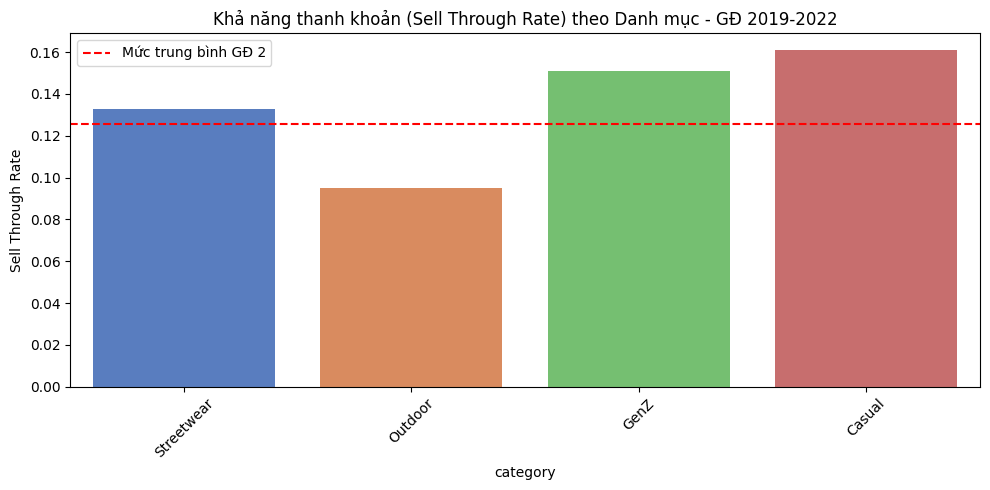

In [12]:
# Lọc lấy dư liệu tồn kho từ 2019-2022
inv_p2 = inventory[inventory['Phase'] == '2019-2022']
# Phân tích theo nhóm danh mục sản phẩm (Category)
cat_overstock = inv_p2.groupby('category').agg({
    'stock_on_hand': 'sum',             # Tổng hàng nằm kẹt trong kho 
    'units_sold': 'sum',                # Tổng bán ra
    'overstock_flag': 'mean',           # Mức độ thường xuyên kẹt hàng
    'sell_through_rate': 'mean'         # Khả năng thanh khoản
}).reset_index()
# Sắp xếp từ kẹt hàng nhiều nhất tới ít nhất
cat_overstock = cat_overstock.sort_values(by='stock_on_hand', ascending=False)
print("\nPHÂN TÍCH TÌNH TRẠNG NGÂM VỐN THEO DANH MỤC (2019-2022):")
display(cat_overstock)
# Vẽ biểu đồ kiểm tra độ thanh khoản của từng Category
plt.figure(figsize=(10, 5))
sns.barplot(data=cat_overstock, x='category', y='sell_through_rate', palette='muted')
plt.title('Khả năng thanh khoản (Sell Through Rate) theo Danh mục - GĐ 2019-2022')
plt.ylabel('Sell Through Rate')
plt.xticks(rotation=45)
plt.axhline(overall_inv['sell_through_rate'].iloc[1], ls='--', color='red', label='Mức trung bình GĐ 2')
plt.legend()
plt.tight_layout()
plt.show()

* Outdoor và Streetwear là hai danh mục có tồn kho lớn nhất nhưng lại có tỷ lệ hàng đã bán so với tổng hàng sẵn có thấp nhất — đặc biệt là Outdoor, chạm đáy chỉ 9.4% với hơn 2.1 triệu sản phẩm tồn và 84.2% số tháng bị overstock. Streetwear cũng không khá hơn: dù bán nhỉnh hơn một chút (13.2%), nhưng lại “gánh” lượng tồn khổng lồ lên tới 2.7 triệu sản phẩm, khiến phần hàng kẹt lại (86.8%) trở thành một núi vốn bị chôn.

* Ngược lại, GenZ và Casual có hiệu suất tốt nhất (15–16%), bán ổn định và thanh khoản cao, nhưng lại được nhập rất dè dặt, dẫn đến tồn kho thấp (chỉ khoảng 176k–300k), không đủ để tận dụng nhu cầu thị trường.

$\rightarrow$ Giai đoạn Covid (2019-2022) khi xu hướng mọi người ra đường dã ngoại giảm sút có thể làm nhu cầu Outdoor và Streetwear suy giảm mạnh, nhưng doanh nghiệp vẫn giữ tư duy dự báo cũ, tiếp tục nhập ồ ạt các dòng này.

#### Follow-up: Liệu công ty có đang sử dụng khuyến mãi đúng cách với những mặt hàng bị nhập thừa?

In [13]:
# 1. Gắn nhãn giai đoạn cho từng đơn hàng
orders['Year'] = orders['order_date'].dt.year
orders['Phase'] = orders['Year'].apply(lambda x: '2012-2018' if x <= 2018 else '2019-2022')
# 2. Hợp nhất Order Items với Orders và Products để quy tụ dữ liệu Category & Giai đoạn
promo_df = pd.merge(order_items, orders[['order_id', 'Phase']], on='order_id', how='left')
promo_df = pd.merge(promo_df, products[['product_id', 'category']], on='product_id', how='left')
# 3. Tạo cờ ghi chú sản phẩm nào có xài mã Khuyến Mãi
promo_df['has_promo'] = promo_df['promo_id'].apply(lambda x: 1 if x != 'No_Promo' else 0)
# Cột phụ để tính số lượng bán ra NHỜ vào khuyến mãi
promo_df['quantity_promo'] = promo_df.apply(lambda x: x['quantity'] if x['has_promo'] == 1 else 0, axis=1)
# 4. Lọc riêng GĐ 2 (2019-2022) và tính xem hiệu suất xả hàng bằng Khuyến mãi
promo_p2 = promo_df[promo_df['Phase'] == '2019-2022'].groupby('category').agg({
    'quantity': 'sum',                 # Tổng hàng bán ra thực tế
    'quantity_promo': 'sum',           # Số hàng bán ra khi CÓ khuyến mãi
    'discount_amount': 'sum'           # Tổng tiền doanh nghiệp rải ra làm khuyến mãi
}).reset_index()
# Tỷ lệ hàng xả được nhờ Khuyến mãi = (Bán có KM / Tổng bán) * 100
promo_p2['Promo_Sales_Ratio (%)'] = (promo_p2['quantity_promo'] / promo_p2['quantity']) * 100
promo_p2 = promo_p2.sort_values(by='Promo_Sales_Ratio (%)', ascending=False).round(2)
print("TIẾN ĐỘ XẢ HÀNG BẰNG CHIẾN DỊCH KHUYẾN MÃI TẠI GĐ 2019-2022:")
display(promo_p2)
# Check bảng Master Khuyến Mãi gốc xem trong Giai đoạn 2, đội Marketing nhắm target ưu đãi vào đâu!
promotions['Phase'] = promotions['start_date'].dt.year.apply(lambda x: '2012-2018' if x <= 2018 else '2019-2022')
promo_targets = promotions[promotions['Phase'] == '2019-2022']['applicable_category'].value_counts().reset_index()
promo_targets.columns = ['Danh mục được KM Nhắm tới', 'Số lượng chiến dịch']
print("\nSỐ LƯỢNG CHIẾN DỊCH KHUYẾN MÃI THIẾT LẬP CHO TỪNG NHÓM (2019-2022):")
display(promo_targets)

TIẾN ĐỘ XẢ HÀNG BẰNG CHIẾN DỊCH KHUYẾN MÃI TẠI GĐ 2019-2022:


,category,quantity,quantity_promo,discount_amount,Promo_Sales_Ratio (%)
2,Outdoor,184736,84574,2.857753e+07,45.78
3,Streetwear,433101,173931,1.684583e+08,40.16
1,GenZ,48955,17371,4.740247e+06,35.48
0,Casual,38572,13443,8.106810e+06,34.85



SỐ LƯỢNG CHIẾN DỊCH KHUYẾN MÃI THIẾT LẬP CHO TỪNG NHÓM (2019-2022):


,Danh mục được KM Nhắm tới,Số lượng chiến dịch
0,Any,16
1,Streetwear,2
2,Outdoor,2


**Nhận xét**

**Kết luận** ...

### Giả thiết: Liệu vấn đề có nằm ở marketing?

In [14]:
# Đảm bảo xử lý ngày tháng cho bảng web_traffic & customers
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
# Gắn nhãn giai đoạn
web_traffic['Phase'] = web_traffic['date'].dt.year.apply(lambda x: '2012-2018' if x <= 2018 else '2019-2022')
customers['Phase'] = customers['signup_date'].dt.year.apply(lambda x: '2012-2018' if x <= 2018 else '2019-2022')

1. ĐỐI CHIẾU CHẤT LƯỢNG TRAFFIC TỔNG THỂ 2 GIAI ĐOẠN

In [15]:
traffic_overall = web_traffic.groupby('Phase').agg({
    'sessions': 'mean',                  # Lưu lượng trung bình ngày
    'page_views': 'mean',                # Xem bao nhiêu trang / ngày
    'bounce_rate': 'mean',               # Mức độ "Vào phát thoát luôn" (%)
    'avg_session_duration_sec': 'mean'   # Thời gian lưu luyến trang web (giây)
}).reset_index().round(2)
print("1. CHẤT LƯỢNG LƯU LƯỢNG TRUY CẬP (TRAFFIC) TỔNG THỂ QUA 2 GIAI ĐOẠN:")
display(traffic_overall)

1. CHẤT LƯỢNG LƯU LƯỢNG TRUY CẬP (TRAFFIC) TỔNG THỂ QUA 2 GIAI ĐOẠN:


,Phase,sessions,page_views,bounce_rate,avg_session_duration_sec
0,2012-2018,22280.20,96803.66,0.0,209.82
1,2019-2022,29183.17,126328.53,0.0,210.98


2. TRUY TÌM NỀN TẢNG MARKETING ĐANG CHẠY CÓ HIỆU QUẢ KÉM NHẤT (GIAI ĐOẠN 2019-2022)

In [16]:
traffic_p2 = web_traffic[web_traffic['Phase'] == '2019-2022']
source_analysis = traffic_p2.groupby('traffic_source').agg({
    'sessions': 'sum',
    'bounce_rate': 'mean',
    'avg_session_duration_sec': 'mean'
}).reset_index().sort_values(by='sessions', ascending=False)

# Mức Bounce rate lý tưởng cho E-commerce thường dưới 40%-50%. Quá mức này là Traffic phế.
print("2. CHI TIẾT TỪNG KÊNH TRAFFIC TRONG GIAI ĐOẠN DOANH THU THẤP (2019-2022):")
display(source_analysis.round(2))

2. CHI TIẾT TỪNG KÊNH TRAFFIC TRONG GIAI ĐOẠN DOANH THU THẤP (2019-2022):


,traffic_source,sessions,bounce_rate,avg_session_duration_sec
2,organic_search,13098029,0.0,210.15
3,paid_search,8990983,0.0,208.45
5,social_media,6940517,0.0,214.48
1,email_campaign,6138828,0.0,214.47
4,referral,4451629,0.0,210.92
0,direct,3016627,0.0,207.40


3. KÊNH LÔI KÉO KHÁCH MỚI (ACQUISITION CHANNEL)

Xem tệp khách hàng đăng ký mới trong GĐ 2 (2019-2022) chủ yếu dội về từ đâu?

In [17]:
acq_channels = customers[customers['Phase'] == '2019-2022']['acquisition_channel'].value_counts().reset_index()
acq_channels.columns = ['Kênh Khách Hàng Đăng Ký', 'Số lượng User Mới']
acq_channels['Tỷ trọng (%)'] = (acq_channels['Số lượng User Mới'] / acq_channels['Số lượng User Mới'].sum() * 100).round(2)
print("3. KÊNH TIẾP THỊ (MARKETING CHANNELS) THU HÚT KHÁCH MỚI NHIỀU NHẤT (2019-2022):")
display(acq_channels)

3. KÊNH TIẾP THỊ (MARKETING CHANNELS) THU HÚT KHÁCH MỚI NHIỀU NHẤT (2019-2022):


,Kênh Khách Hàng Đăng Ký,Số lượng User Mới,Tỷ trọng (%)
0,organic_search,21650,29.85
1,social_media,14505,20.00
2,paid_search,14461,19.94
3,email_campaign,8768,12.09
4,referral,7331,10.11
5,direct,5811,8.01
